In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

Nx = Ny = Nz = 100
dx = dy = dz = 15e-3
cx, cy, cz = Nx // 2, Ny // 2, 1
L = Nx * dx # dimensao do grid

# condição CFL para estabilidade
dt = 0.99 / (vp * np.sqrt(
    (1/dx**2) + (1/dy**2) + (1/dz**2)
))
Nt = 70
T = Nt * dt

# define os grids - desenha a célula de Yee 3D
grid_x_base = np.linspace(0, L, Nx + 1)
grid_y_base = np.linspace(0, L, Ny + 1)
grid_z_base = np.linspace(0, L, Nz + 1)

grid_x_Ex = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Ex = np.linspace(0, L, Ny + 1)
grid_z_Ex = np.linspace(0, L, Nz + 1)

grid_x_Ey = np.linspace(0, L, Nx + 1)
grid_y_Ey = np.linspace(dy/2, L - dy/2, Ny)
grid_z_Ey = np.linspace(0, L, Nz + 1)

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_z_Ez = np.linspace(dz/2, L - dz/2, Nz)

grid_x_Hx = np.linspace(0, L, Nx + 1)
grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
grid_z_Hx = np.linspace(dz/2, L - dz/2, Nz)

grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hy = np.linspace(0, L, Ny + 1)
grid_z_Hy = np.linspace(dz/2, L - dz/2, Nz)

grid_x_Hz = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hz = np.linspace(dy/2, L - dy/2, Ny)
grid_z_Hz = np.linspace(0, L, Nz + 1)

# ponta de prova para coletar pontos
probe = []
pcx, pcy, pcz = cx + 10, cy + 10, cz + 10

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(0, Nt - 2, 3, dtype=int)
# n_snapshots = range(Nt-1)
n_snapshots = [Nt // 3, Nt//2, 2 * (Nt // 3)]
# n_snapshots = [50, 60, 68]
Ez_snapshots = []

Ex = Ex_next = np.zeros((grid_x_Ex.shape[0], grid_y_Ex.shape[0],  grid_z_Ex.shape[0]))
Ey = Ey_next = np.zeros((grid_x_Ey.shape[0], grid_y_Ey.shape[0],  grid_z_Ey.shape[0]))
Ez = Ez_next = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0],  grid_z_Ez.shape[0]))
Hx = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0],  grid_z_Hx.shape[0]))
Hy = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0],  grid_z_Hy.shape[0]))
Hz = Hz_next = np.zeros((grid_x_Hz.shape[0], grid_y_Hz.shape[0],  grid_z_Hz.shape[0]))

In [12]:
for n in range(Nt-1):
    # --- fonte (senoidal no tempo) ---
    frequency = 1e9  # 1 GHz
    voltage_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez[cx, cy, cz] += voltage_senoidal / dz

    # --- Update H fields ---
    # Hx
    Hx_next[:, :, :] = Hx[:, :, :] - (dt/mu)*(
        (Ez[:, 1:, :] - Ez[:, :-1, :])/dy -
        (Ey[:, :, 1:] - Ey[:, :, :-1])/dz
    )

    # Hy
    Hy_next[:, :, :] = Hy[:, :, :] - (dt/mu)*(
        (Ex[:, :, 1:] - Ex[:, :, :-1])/dz -
        (Ez[1:, :, :] - Ez[:-1, :, :])/dx
    )

    # Hz
    Hz_next[:, :, :] = Hz[:, :, :] - (dt/mu)*(
        (Ey[1:, :, :] - Ey[:-1, :, :])/dx -
        (Ex[:, 1:, :] - Ex[:, :-1, :])/dy
    )

    # --- Update E fields ---
    # Ex
    Ex_next[:, 1:-1, 1:-1] = Ex[:, 1:-1, 1:-1] + (dt/eps)*(
        (Hz_next[:, 1:, 1:-1] - Hz_next[:, :-1, 1:-1])/dy -
        (Hy_next[:, 1:-1, 1:] - Hy_next[:, 1:-1, :-1])/dz
    )

    # Ey
    Ey_next[1:-1, :, 1:-1] = Ey[1:-1, :, 1:-1] + (dt/eps)*(
        (Hx_next[1:-1, :, 1:] - Hx_next[1:-1, :, :-1])/dz -
        (Hz_next[1:, :, 1:-1] - Hz_next[:-1, :, 1:-1])/dx
    )

    # Ez
    Ez_next[1:-1, 1:-1, :] = Ez[1:-1, 1:-1, :] + (dt/eps)*(
        (Hy_next[1:, 1:-1, :] - Hy_next[:-1, 1:-1, :])/dx -
        (Hx_next[1:-1, 1:, :] - Hx_next[1:-1, :-1, :])/dy
    )

    # fixa 0 em 5 celulas de grid acima da antena, sendo PEC
    Ez_next[cx, cy, (cz+1):(cz+6)] = 0
    Ey_next[cx, cy, (cz+1):(cz+6)] = 0
    Ex_next[cx, cy, (cz+1):(cz+6)] = 0

    # fixa 0 em todo o plano de ground embaixo
    Ez_next[:, :, 0] = 0
    Ey_next[:, :, 0] = 0
    Ex_next[:, :, 0] = 0

    # salva o valor no centro para a FFT
    probe.append(Ez_next[pcx, pcy, pcz])

    # atualiza os campos para o próximo passo
    Ex, Ex_next = Ex_next, Ex
    Ey, Ey_next = Ey_next, Ey
    Ez, Ez_next = Ez_next, Ez

    Hx, Hx_next = Hx_next, Hx
    Hy, Hy_next = Hy_next, Hy
    Hz, Hz_next = Hz_next, Hz

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez.copy())



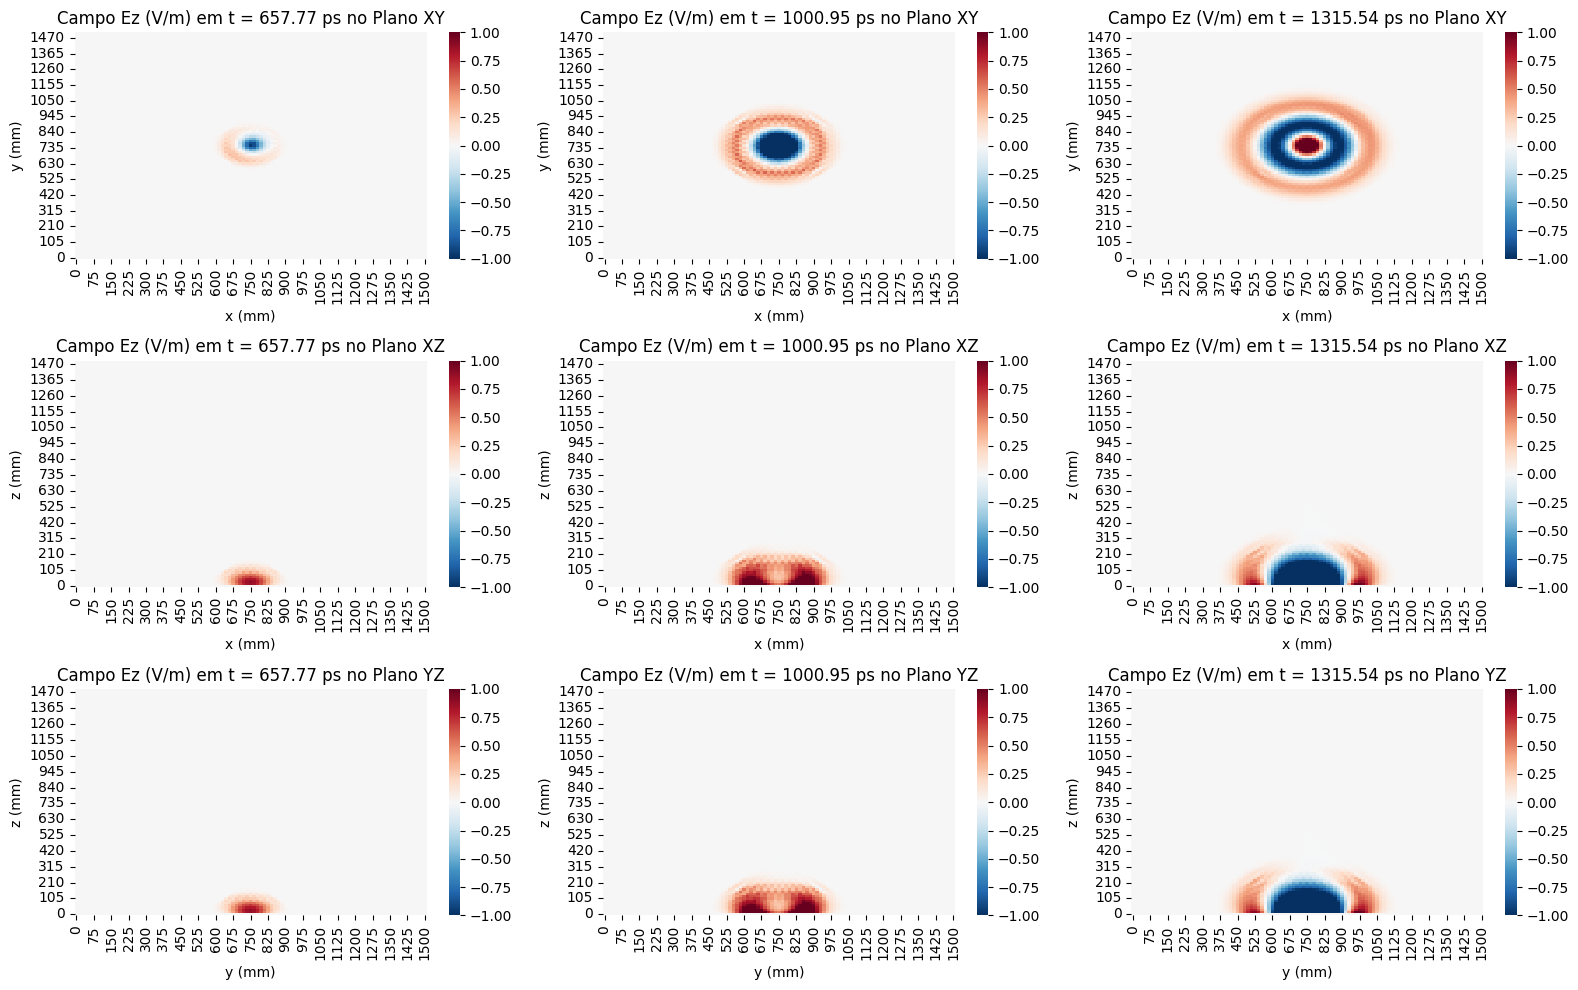

In [21]:
# prepara para os plots 3D
xy_snaps = []
xz_snaps = []
yz_snaps = []
dist_from_center = 10 * dx
idx_from_center = int(dist_from_center / dx)

for n in range(len(n_snapshots)):
    F = Ez_snapshots[n]
    xy_snaps.append(F[:, :, cz + idx_from_center])
    xz_snaps.append(F[:, cy + idx_from_center, :])
    yz_snaps.append(F[cx + idx_from_center, :, :])

fig, axes = plt.subplots(3,3, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    idx = i % 3
    target_arr = []
    title = ""
    xlabel = ""
    ylabel = ""

    if i < 3: 
        target_arr = xy_snaps
        title = "Plano XY"
        xlabel = "x (mm)"
        ylabel = "y (mm)"
    if 3 <= i < 6: 
        target_arr = xz_snaps
        title = "Plano XZ"
        xlabel = "x (mm)"
        ylabel = "z (mm)"
    if 6 <= i < 9: 
        target_arr = yz_snaps
        title = "Plano YZ"
        xlabel = "y (mm)"
        ylabel = "z (mm)"

    sns.heatmap(target_arr[idx].T, ax=ax, annot=False, cmap='RdBu_r',vmin=-1,vmax=1,center=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[idx]*dt*1e12:.2f} ps no {title}")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()


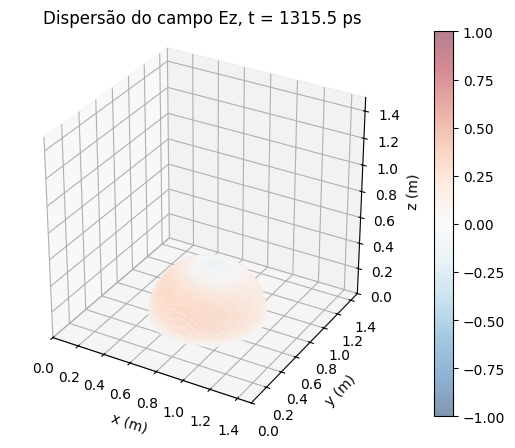

In [25]:
# prepara para os plots 3D
X, Y, Z = np.meshgrid(grid_x_Ez, grid_y_Ez, grid_z_Ez, indexing='ij')

# Example radial field (decaying)
snap_idx = 2
F = Ez_snapshots[snap_idx]

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')

# nesse instante t, a onda atingiu a seguinte distancia
distance_reached = vp * n_snapshots[snap_idx] * dt

# valores fora da máscara recebem NaN, e assim renderiza melhor o plot
mask = (X.flatten() - cx * dx)**2 + (Y.flatten() - cy * dy)**2 + (Z.flatten() - cz * dz)**2 <= distance_reached**2

sc = ax.scatter(
    X.flatten()[mask],
    Y.flatten()[mask],
    Z.flatten()[mask],
    c=F.flatten()[mask],
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    s=1,
    alpha=0.5
)

plt.colorbar(sc)
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_zlim(0, L)
ax.set_box_aspect([1,1,1])
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title(f"Dispersão do campo Ez, t = {n_snapshots[snap_idx] * dt * 1e12:.1f} ps")

plt.show()

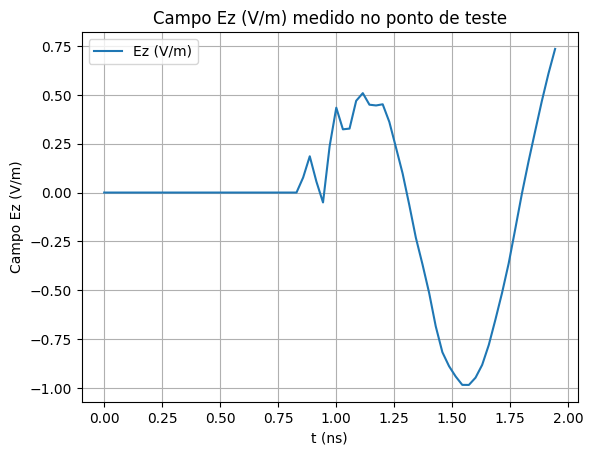

In [15]:
tgrid = range(len(probe)) * dt * 1e9
plt.plot(tgrid, probe, label="Ez (V/m)")
plt.title("Campo Ez (V/m) medido no ponto de teste")
plt.xlabel("t (ns)")
plt.ylabel("Campo Ez (V/m)")
plt.legend()
plt.grid()
plt.show()